# Semi-Supervised and Active Learning

Two studies on what label information is worth. The first fixes 30 train and test splits and compares a fully supervised SVM against self-training, k-means and spectral clustering: supervised accuracy averages 0.9708, while the two clustering methods stall near 0.88, held back by recall close to 0.73 on the malignant class. The second asks whether choosing which points to label beats labelling at random, growing the training pool from 10 to 900 points.

**Data:** Breast Cancer Wisconsin (Diagnostic), 569 instances with 30 features; and banknote authentication, 1,372 instances with 4 features; UCI Machine Learning Repository
https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
https://archive.ics.uci.edu/dataset/267/banknote+authentication

## Models
| Model | Section | What it does |
|---|---|---|
| L1-penalized linear SVM, supervised | Supervised baseline | C by 5-fold cross-validation; repeated over 30 splits |
| Self-training SVM | Self-training | Half the labels hidden, then pseudo-labelled one point at a time, farthest from the boundary first |
| K-means, k = 2 | K-means | Clusters labelled by majority vote of the 30 points nearest each center |
| Spectral clustering, RBF affinity | Spectral clustering | Gamma picked so cluster sizes match the class balance |
| K-nearest neighbors, k = 3 | Spectral clustering | Assigns test points to spectral clusters, which have no centers |
| Passive learning SVM | Passive learning | Random pools growing from 10 to 900 points; 50 repeats |
| Active learning SVM | Active learning | Same schedule; the 10 points nearest the boundary added each step |

## Contents
| Section | What it covers |
|---|---|
| Supervised baseline | L1-penalized SVM with C from 5-fold cross-validation, repeated over 30 splits |
| Self-training | Half the training labels hidden, then pseudo-labelled one point at a time, starting farthest from the boundary |
| K-means | Two clusters on normalized features, labelled by majority vote of the 30 points nearest each center |
| Spectral clustering | RBF affinity with gamma picked to match the class balance; test points assigned by 3-nearest-neighbor |
| Method comparison | Accuracy, precision, recall, F1 and AUC averaged across the 30 runs |
| Passive learning | SVMs on random pools growing from 10 to 900 points, repeated 50 times |
| Active learning | The same schedule, adding the 10 points nearest the decision boundary at each step |
| Learning curves | Average train and test error against pool size for both strategies |

## 1. Supervised, Semi-Supervised, and Unsupervised Learning

Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.cluster import SpectralClustering
from sklearn.neighbors import KNeighborsClassifier

from scipy.special import softmax
from scipy.stats import mode


### (a) Download the Breast Cancer Wisconsin (Diagnostic) Data Set

Download the Breast Cancer Wisconsin (Diagnostic) Data Set from:
https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

Dataset contains 569 instances of breast mass samples, each described by an ID, a diagnosis label, and 30 real-valued features computed from digitized images of fine needle aspirates. For each of 10 base nuclear measurements, the **mean**, **standard error**, and **"worst"** values are reported, giving 30 features total.

| Variable Name | Role | Type |
| :--- | :--- | :--- |
| **diagnosis** | Target | `M` (malignant), `B` (benign) |
| **ID** | Dropped | Integer |
| **radius** | Feature | Real |
| **texture** | Feature | Real |
| **perimeter** | Feature | Real |
| **area** | Feature | Real |
| **smoothness** | Feature | Real |
| **compactness** | Feature | Real |
| **concavity** | Feature | Real |
| **concave_points** | Feature | Real |
| **symmetry** | Feature | Real |
| **fractal_dimension** | Feature | Real |

In [2]:
breast_full_df = pd.read_csv('data/wdbc.data', header=None)

base_feat = ['radius', 'texture', 'perimeter', 'area', 'smoothness', 'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']
col_names = ['ID', 'diagnosis']
for stat in ['mean', 'se', 'worst']:
    for feature in base_feat:
        col_names.append(feature + '_' + stat)

breast_full_df.columns = col_names
breast_full_df = breast_full_df.drop(columns=['ID'])
breast_full_df['diagnosis'] = breast_full_df['diagnosis'].map({'M': 1, 'B': 0})

y_full_df = breast_full_df['diagnosis'].values
X_full_df = breast_full_df.drop(columns=['diagnosis']).values

print('Shape:', breast_full_df.shape)

display(breast_full_df)

Shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


### (b) Monte-Carlo Simulation
Repeat the following procedures for supervised, unsupervised, and semi-supervised learning M = 30 times, and use randomly se- lected train and test data (make sure you use 20% of both the positve and negative classes as the test set).

In [3]:
M = 30
mc_split_list = []
feature_col = col_names.copy()
feature_col.remove('diagnosis')
feature_col.remove('ID')

for i in range(M):
    X_train, X_test, y_train, y_test = train_test_split(X_full_df, y_full_df, test_size=0.2, stratify=y_full_df, random_state=i + 41)
    mc_split_list.append({
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    })

def add_scores(y_true, y_pred, y_scores, target_dict):
    target_dict['acc'].append(accuracy_score(y_true, y_pred))
    target_dict['prec'].append(precision_score(y_true, y_pred))
    target_dict['rec'].append(recall_score(y_true, y_pred))
    target_dict['f1'].append(f1_score(y_true, y_pred))
    target_dict['auc'].append(roc_auc_score(y_true, y_scores))

def get_roc_conf_matrix(ex_run_data):
    print("\nTraining Confusion Matrix (run 0):")
    print(confusion_matrix(ex_run_data['y_train'], ex_run_data['y_train_pred']))
    print("\nTesting Confusion Matrix (run 0):")
    print(confusion_matrix(ex_run_data['y_test'], ex_run_data['y_test_pred']))

    plt.style.use('default')
    fpr_train, tpr_train, _ = roc_curve(ex_run_data['y_train'], ex_run_data['y_train_scores'])
    fpr_test, tpr_test, _ = roc_curve(ex_run_data['y_test'], ex_run_data['y_test_scores'])
    auc_train = roc_auc_score(ex_run_data['y_train'], ex_run_data['y_train_scores'])
    auc_test = roc_auc_score(ex_run_data['y_test'], ex_run_data['y_test_scores'])

    plt.figure(figsize=(7, 5))
    plt.plot(fpr_train, tpr_train, color='blue', label=f"Train AUC = {auc_train:.4f}")
    plt.plot(fpr_test, tpr_test, color='green', label=f"Test AUC = {auc_test:.4f}")
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')
    plt.title('ROC Curve')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.legend()
    plt.show()

#### (i) Supervised Learning
Train an L1-penalized SVM on the full labeled training set, use 5-fold cross-validation to select the penalty parameter C.

,Split,Train Accuracy,Test Accuracy,Best C
0,1,0.993407,0.982456,0.464159
1,2,0.984615,0.956140,0.464159
2,3,0.986813,0.991228,0.161560
3,4,0.980220,0.921053,0.019573
4,5,0.989011,0.973684,0.056234
5,6,0.973626,0.982456,0.019573
6,7,0.986813,0.973684,0.161560
7,8,0.993407,0.938596,0.464159
8,9,0.982418,0.991228,0.464159
9,10,0.986813,0.973684,0.056234


Average scores across 30 splits:


,train,test
acc,0.9872,0.9708
prec,0.9938,0.9744
rec,0.9718,0.9460
f1,0.9826,0.9596
auc,0.9974,0.9931



Training Confusion Matrix (run 0):
[[285   0]
 [  3 167]]

Testing Confusion Matrix (run 0):
[[72  0]
 [ 2 40]]


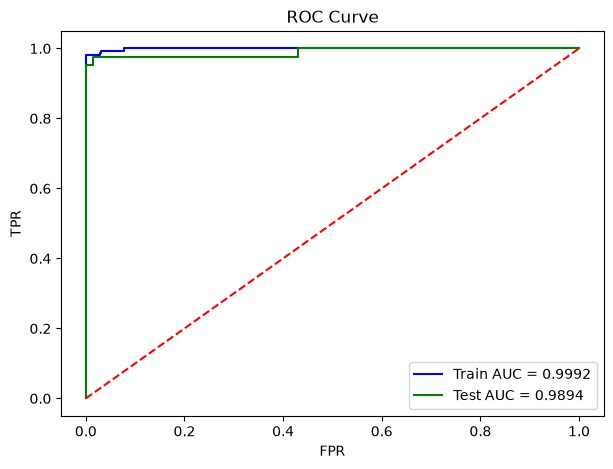

In [4]:
score_super_dir = {
    'train': {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []},
    'test': {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
}
run_0_sup = {}
sup_best_C = []
for i in range(M):
    X_train = mc_split_list[i]['X_train']
    X_test = mc_split_list[i]['X_test']
    y_train = mc_split_list[i]['y_train']
    y_test = mc_split_list[i]['y_test']

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    C_grid = {'C': np.logspace(-4, 7, 25)}
    SVM = LinearSVC(penalty='l1', dual=False, max_iter=100000, random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    param_CV_l1 = GridSearchCV(SVM, C_grid, cv=cv, scoring='balanced_accuracy', n_jobs=-1)

    param_CV_l1.fit(X_train, y_train)
    best_svm = param_CV_l1.best_estimator_
    sup_best_C.append(param_CV_l1.best_params_['C'])

    y_train_pred = best_svm.predict(X_train)
    y_test_pred = best_svm.predict(X_test)
    y_train_scores = best_svm.decision_function(X_train)
    y_test_scores = best_svm.decision_function(X_test)

    add_scores(y_train, y_train_pred, y_train_scores, score_super_dir['train'])
    add_scores(y_test, y_test_pred, y_test_scores, score_super_dir['test'])

    if i == 0:
        run_0_sup = {
            'y_train': y_train, 'y_train_pred': y_train_pred, 'y_train_scores': y_train_scores,
            'y_test': y_test, 'y_test_pred': y_test_pred, 'y_test_scores': y_test_scores
        }

iter_df = pd.DataFrame({
    'Split': range(1, M + 1),
    'Train Accuracy': score_super_dir['train']['acc'],
    'Test Accuracy': score_super_dir['test']['acc'],
    'Best C': sup_best_C
})
display(iter_df)

avg_scores_sup = {split: {m: np.mean(score_super_dir[split][m]) for m in score_super_dir[split]} for split in ['train', 'test']}
print("Average scores across 30 splits:")
avg_scores_sup_df = pd.DataFrame(avg_scores_sup)
display(avg_scores_sup_df.round(4))
get_roc_conf_matrix(run_0_sup)

#### (ii) Semi-Supervised Learning/ Self-training
Within each Monte Carlo split, select 50% of the positive class along with 50% of the negative class in the training set as labeled data and the rest as unlabelled data. Train an L1-penalized SVM on the labeled half with 5-fold cross-validation to select C, then iteratively pseudo-label the unlabeled point farthest from the decision boundary, add it to the labeled set, and retrain the SVM (reuse same C) until the unlabeled pool is empty.

##### (A) and (B)

,Split,Train Accuracy,Test Accuracy,Best C
0,1,0.973626,0.973684,1.333521
1,2,0.971429,0.973684,0.161560
2,3,0.973626,0.964912,0.161560
3,4,0.986813,0.912281,261.015722
4,5,0.973626,0.982456,0.464159
5,6,0.971429,0.991228,0.056234
6,7,0.975824,0.964912,0.161560
7,8,0.975824,0.964912,0.464159
8,9,0.975824,0.956140,0.464159
9,10,0.969231,0.947368,0.464159


Average scores across 30 splits (semi-supervised):


,train,test
acc,0.9747,0.9655
prec,0.9816,0.9647
rec,0.9506,0.9429
f1,0.9656,0.9528
auc,0.9939,0.9917



Training Confusion Matrix (run 0):
[[280   5]
 [  7 163]]

Testing Confusion Matrix (run 0):
[[71  1]
 [ 2 40]]


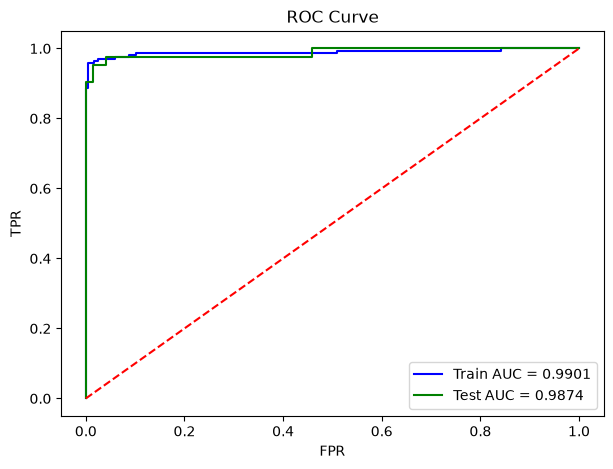

In [5]:
score_semi_dir = {
    'train': {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []},
    'test': {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
}
run_0_semi = {}
semi_best_C = []

for i in range(M):
    X_train = mc_split_list[i]['X_train']
    X_test = mc_split_list[i]['X_test']
    y_train = mc_split_list[i]['y_train']
    y_test = mc_split_list[i]['y_test']

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    X_lab, X_unlab, y_lab, y_unlab = train_test_split(X_train, y_train, test_size=0.5, stratify=y_train, random_state=i + 41)

    # Part A
    C_grid = {'C': np.logspace(-4, 7, 25)}
    SVM = LinearSVC(penalty='l1', dual=False, max_iter=100000, random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    param_CV_l1 = GridSearchCV(SVM, C_grid, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
    param_CV_l1.fit(X_lab, y_lab)
    best_C = param_CV_l1.best_params_['C']
    semi_best_C.append(best_C)

    # Part B
    while len(X_unlab) > 0:
        clf = LinearSVC(penalty='l1', dual=False, C=best_C, max_iter=100000, random_state=42)
        clf.fit(X_lab, y_lab)
        scores = clf.decision_function(X_unlab)
        idx = np.argmax(np.abs(scores))
        pseudo_label = clf.predict(X_unlab[idx].reshape(1, -1))[0]
        X_lab = np.vstack([X_lab, X_unlab[idx]])
        y_lab = np.append(y_lab, pseudo_label)
        X_unlab = np.delete(X_unlab, idx, axis=0)
        y_unlab = np.delete(y_unlab, idx)

    final_svm = LinearSVC(penalty='l1', dual=False, C=best_C, max_iter=100000, random_state=42)
    final_svm.fit(X_lab, y_lab)

    y_train_pred = final_svm.predict(X_train)
    y_test_pred = final_svm.predict(X_test)
    y_train_scores = final_svm.decision_function(X_train)
    y_test_scores = final_svm.decision_function(X_test)

    add_scores(y_train, y_train_pred, y_train_scores, score_semi_dir['train'])
    add_scores(y_test, y_test_pred, y_test_scores, score_semi_dir['test'])

    if i == 0:
        run_0_semi = {
            'y_train': y_train, 'y_train_pred': y_train_pred, 'y_train_scores': y_train_scores,
            'y_test': y_test, 'y_test_pred': y_test_pred, 'y_test_scores': y_test_scores
        }

iter_df_semi = pd.DataFrame({
    'Split': range(1, M + 1),
    'Train Accuracy': score_semi_dir['train']['acc'],
    'Test Accuracy': score_semi_dir['test']['acc'],
    'Best C': semi_best_C
})
display(iter_df_semi)

avg_scores_semi = {split: {m: np.mean(score_semi_dir[split][m]) for m in score_semi_dir[split]} for split in ['train', 'test']}
print("Average scores across 30 splits (semi-supervised):")
avg_scores_semi_df = pd.DataFrame(avg_scores_semi)
display(avg_scores_semi_df.round(4))

get_roc_conf_matrix(run_0_semi)

#### (iii) Unsupervised Learning
Run K-means with k=2 on the training set, ignoring labels, with multiple random initializations to avoid local minima. Assign a class label to each cluster by majority vote of the 30 nearest training points to its center, then evaluate the resulting classifier on the training set and on the test set by proximity to cluster centers.

##### (A), (B), (C)

,Split,Train Accuracy,Test Accuracy
0,1,0.883516,0.894737
1,2,0.890110,0.877193
2,3,0.896703,0.868421
3,4,0.879121,0.894737
4,5,0.898901,0.885965
5,6,0.892308,0.885965
6,7,0.887912,0.894737
7,8,0.898901,0.850877
8,9,0.887912,0.877193
9,10,0.876923,0.903509



Average scores across 30 splits:


,train,test
acc,0.8867,0.8936
prec,0.9558,0.9686
rec,0.7306,0.7349
f1,0.8279,0.8350
auc,0.9499,0.9522



Training Confusion Matrix (run 0):
[[279   6]
 [ 47 123]]

Testing Confusion Matrix (run 0):
[[71  1]
 [11 31]]


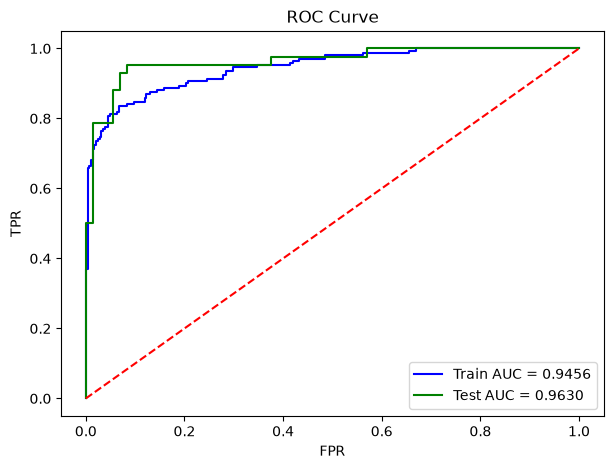

In [6]:
score_unsup_k_dir = {
    'train': {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []},
    'test':  {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
}
run_0_unsup_k = {}

for i in range(M):
    X_train = mc_split_list[i]['X_train']
    X_test  = mc_split_list[i]['X_test']
    y_train = mc_split_list[i]['y_train']
    y_test  = mc_split_list[i]['y_test']

    norm = Normalizer()
    X_train = norm.fit_transform(X_train)
    X_test = norm.transform(X_test)

    # Part A
    kmeans = KMeans(n_clusters=2, n_init=20, init='random', random_state=i + 41)
    kmeans.fit(X_train)
    centers = kmeans.cluster_centers_
    train_clust = kmeans.labels_
    train_dist = euclidean_distances(X_train, centers)

    # Part B
    cluster_class = {}
    for c in [0, 1]:
        distances_to_center = train_dist[:, c]
        close_30_points = np.argsort(distances_to_center)[:30]
        closest_labels = y_train[close_30_points]
        majority_label = mode(closest_labels, keepdims=False).mode
        cluster_class[c] = int(majority_label)

    y_train_pred = np.array([cluster_class[c] for c in train_clust])
    train_softmax = softmax(-train_dist, axis=1)
    y_train_scores = train_softmax[:, 0] if cluster_class[0] == 1 else train_softmax[:, 1]

    add_scores(y_train, y_train_pred, y_train_scores, score_unsup_k_dir['train'])

    # Part C
    test_clusters = kmeans.predict(X_test)
    y_test_pred = np.array([cluster_class[c] for c in test_clusters])
    test_distances = euclidean_distances(X_test, centers)
    test_softmax = softmax(-test_distances, axis=1)
    y_test_scores = test_softmax[:, 0] if cluster_class[0] == 1 else test_softmax[:, 1]

    add_scores(y_test, y_test_pred, y_test_scores, score_unsup_k_dir['test'])

    if i == 0:
        run_0_unsup_k = {
            'y_train': y_train, 'y_train_pred': y_train_pred, 'y_train_scores': y_train_scores,
            'y_test':  y_test,  'y_test_pred':  y_test_pred,  'y_test_scores':  y_test_scores
        }

iter_df_unsup_k = pd.DataFrame({
    'Split': range(1, M + 1),
    'Train Accuracy': score_unsup_k_dir['train']['acc'],
    'Test Accuracy': score_unsup_k_dir['test']['acc']
})
display(iter_df_unsup_k)

avg_scores_unsup_k = {split: {m: np.mean(score_unsup_k_dir[split][m]) for m in score_unsup_k_dir[split]} for split in ['train', 'test']}
print("\nAverage scores across 30 splits:")
avg_scores_unsup_k_df = pd.DataFrame(avg_scores_unsup_k)
display(avg_scores_unsup_k_df.round(4))

get_roc_conf_matrix(run_0_unsup_k)

#### (iv) Spectral Clustering
Run spectral clustering with k=2 and an RBF on the training set (ignor labels). Search for a gamma value whose two cluster sizes most closely match the original class balance (p malignant, n benign), determined on the first MC split and reused for all runs. Assign a class label to each cluster by majority vote of its members, then evaluate the resulting classifier on the training set and on the test set, (where test cluster class are determined from training via 3-nearest-neighbor).

Best gamma found on split 0: 0.0010


,Split,Train Accuracy,Test Accuracy
0,1,0.881319,0.885965
1,2,0.881319,0.877193
2,3,0.890110,0.859649
3,4,0.876923,0.885965
4,5,0.894505,0.877193
5,6,0.885714,0.859649
6,7,0.883516,0.894737
7,8,0.894505,0.824561
8,9,0.883516,0.868421
9,10,0.872527,0.894737


Average scores across 30 splits:


,train,test
acc,0.8823,0.8807
prec,0.9565,0.9522
rec,0.7178,0.7119
f1,0.8200,0.8134
auc,0.9493,0.9517



Training Confusion Matrix (run 0):
[[280   5]
 [ 49 121]]

Testing Confusion Matrix (run 0):
[[71  1]
 [12 30]]


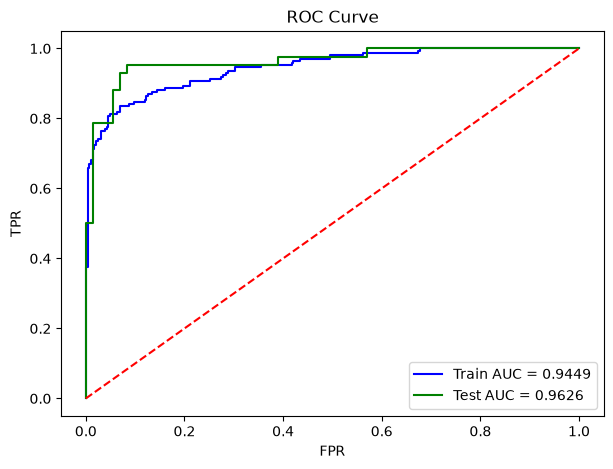

In [7]:
score_unsup_s_dir = {
    'train': {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []},
    'test':  {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
}
run_0_unsup_s = {}

gamma_range = np.logspace(-3, 1, 15)
best_gamma = None

for i in range(M):
    X_train = mc_split_list[i]['X_train']
    X_test  = mc_split_list[i]['X_test']
    y_train = mc_split_list[i]['y_train']
    y_test  = mc_split_list[i]['y_test']

    norm = Normalizer()
    X_train = norm.fit_transform(X_train)
    X_test = norm.transform(X_test)

    # Find best gamma on the first split
    if i == 0:
        target_p = np.sum(y_train == 1)
        target_n = np.sum(y_train == 0)

        best_diff = np.inf
        for g in gamma_range:
            spec_try = SpectralClustering(n_clusters=2, affinity='rbf', gamma=g, random_state=i + 41)
            labels_try = spec_try.fit_predict(X_train)
            size_0 = np.sum(labels_try == 0)
            size_1 = np.sum(labels_try == 1)
            cluster_sizes = sorted([size_0, size_1])
            target_sizes = sorted([target_p, target_n])
            diff = abs(cluster_sizes[0] - target_sizes[0]) + abs(cluster_sizes[1] - target_sizes[1])
            if diff < best_diff:
                best_diff = diff
                best_gamma = g

        print(f"Best gamma found on split 0: {best_gamma:.4f}")

    # Part A
    spectral = SpectralClustering(n_clusters=2, affinity='rbf', gamma=best_gamma, random_state=i + 41)
    train_clust = spectral.fit_predict(X_train)

    centers = np.array([
        X_train[train_clust == 0].mean(axis=0),
        X_train[train_clust == 1].mean(axis=0)
    ])

    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train, train_clust)
    test_clust = knn.predict(X_test)

    # Part B
    cluster_class = {}
    for c in [0, 1]:
        members = y_train[train_clust == c]
        cluster_class[c] = int(mode(members, keepdims=False).mode) if len(members) > 0 else 0

    train_dist = euclidean_distances(X_train, centers)
    train_softmax = softmax(-train_dist, axis=1)

    y_train_pred = np.array([cluster_class[c] for c in train_clust])
    y_train_scores = train_softmax[:, 0] if cluster_class[0] == 1 else train_softmax[:, 1]
    add_scores(y_train, y_train_pred, y_train_scores, score_unsup_s_dir['train'])

    test_dist = euclidean_distances(X_test, centers)
    test_softmax = softmax(-test_dist, axis=1)

    y_test_pred = np.array([cluster_class[c] for c in test_clust])
    y_test_scores = test_softmax[:, 0] if cluster_class[0] == 1 else test_softmax[:, 1]
    add_scores(y_test, y_test_pred, y_test_scores, score_unsup_s_dir['test'])

    if i == 0:
        run_0_unsup_s = {
            'y_train': y_train, 'y_train_pred': y_train_pred, 'y_train_scores': y_train_scores,
            'y_test':  y_test,  'y_test_pred':  y_test_pred,  'y_test_scores':  y_test_scores
        }

iter_df_unsup_s = pd.DataFrame({
    'Split': range(1, M + 1),
    'Train Accuracy': score_unsup_s_dir['train']['acc'],
    'Test Accuracy': score_unsup_s_dir['test']['acc']
})
display(iter_df_unsup_s)

avg_scores_unsup_s = {split: {m: np.mean(score_unsup_s_dir[split][m]) for m in score_unsup_s_dir[split]} for split in ['train', 'test']}
print("Average scores across 30 splits:")
avg_scores_unsup_s_df = pd.DataFrame(avg_scores_unsup_s)
display(avg_scores_unsup_s_df.round(4))

get_roc_conf_matrix(run_0_unsup_s)

#### (v) Compare

In [8]:
comp_df = pd.concat({
    'Supervised': avg_scores_sup_df,
    'Semi-Supervised': avg_scores_semi_df,
    'K-means': avg_scores_unsup_k_df,
    'Spectral':avg_scores_unsup_s_df
}, axis=1).round(4)

print("Average metrics across 30 MC runs for all 4 methods:")
display(comp_df.T)

Average metrics across 30 MC runs for all 4 methods:


acc    prec     rec      f1     auc
Supervised      train  0.9872  0.9938  0.9718  0.9826  0.9974
                test   0.9708  0.9744  0.9460  0.9596  0.9931
Semi-Supervised train  0.9747  0.9816  0.9506  0.9656  0.9939
                test   0.9655  0.9647  0.9429  0.9528  0.9917
K-means         train  0.8867  0.9558  0.7306  0.8279  0.9499
                test   0.8936  0.9686  0.7349  0.8350  0.9522
Spectral        train  0.8823  0.9565  0.7178  0.8200  0.9493
                test   0.8807  0.9522  0.7119  0.8134  0.9517

Supervised SVM performed best (test acc = 0.9708, AUC = 0.9931), semi-supervised self-training has slightly lower performance (test acc = 0.9655, AUC = 0.9917), and the two unsupervised methods had significantly lower score, for K-means (test acc = 0.8936, AUC = 0.9522) and spectral (test acc = 0.8807, AUC = 0.9517). The unsupervised methods can only recover natural geometric structure and assign class labels via post-hoc majority vote, confirming that label information meaningfully improves classification performance. Additionally recall is the weakest metric for the unsupervised methods of around 0.72 vs around 0.95 for supervised, meaning they miss a substantial fraction of malignant class.

## 2. Active Learning Using Support Vector Machines

### (a) Download the banknote authentication Data Set
Download the banknote authentication data set from: https://archive.ics.uci.edu/dataset/267/banknote+authentication

Data were extracted from images that were taken from genuine and forged banknote-like specimens.

| Variable Name | Role | Description                               |
|---|---|-------------------------------------------|
| variance | Feature | Variance of the wavelet transformed image |
| skewness | Feature | Skewness of the wavelet transformed image |
| kurtosis | Feature | Kurtosis of the wavelet transformed image |
| entropy | Feature | Entropy of the image                      |
| class | Target | Binary label (0 or 1)                     |

In [9]:
bank_col_names = ['variance', 'skewness', 'kurtosis', 'entropy', 'class']
banknote_df = pd.read_csv('data/data_banknote_authentication.txt', header=None, names=bank_col_names)

display(banknote_df)

X_full_bank = banknote_df.drop(columns=['class']).values
y_full_bank = banknote_df['class'].values


,variance,skewness,kurtosis,entropy,class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


### (b) Repeat each of the following two procedures 50 times

In [10]:
M_bank = 50
mc_split_list_bank = []

for i in range(M_bank):
    X_train_bank, X_test_bank, y_train_bank, y_test_bank = train_test_split(X_full_bank, y_full_bank, test_size=472, stratify=y_full_bank, random_state=i + 41)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_bank)
    X_test_scaled = scaler.transform(X_test_bank)

    mc_split_list_bank.append({
        'X_train': X_train_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train_bank,
        'y_test': y_test_bank
    })


#### (i) Passive

In [11]:
train_set_size = list(range(10, 901, 10))
C_grid = {'C': np.logspace(-3, 2, 10)}

passive_err = {
    'train': {size: [] for size in train_set_size},
    'test':  {size: [] for size in train_set_size}
}

for i in range(M_bank):
    X_train = mc_split_list_bank[i]['X_train']
    X_test  = mc_split_list_bank[i]['X_test']
    y_train = mc_split_list_bank[i]['y_train']
    y_test  = mc_split_list_bank[i]['y_test']

    indexes = np.arange(len(X_train))
    rand = np.random.RandomState(i + 41)
    rand.shuffle(indexes)

    while sum(y_train[indexes[:10]]) != 5:
        rand.shuffle(indexes)

    for m in train_set_size:
        train_index = indexes[:m]
        X_subset = X_train[train_index]
        y_subset = y_train[train_index]

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        SVM = LinearSVC(penalty='l1', dual=False, max_iter=100000, random_state=42)
        param_CV_l1 = GridSearchCV(SVM, C_grid, cv=cv, scoring='accuracy', n_jobs=-1)
        param_CV_l1.fit(X_subset, y_subset)
        best_svm = param_CV_l1.best_estimator_

        y_train_pred = best_svm.predict(X_train)
        y_test_pred = best_svm.predict(X_test)

        passive_err['train'][m].append(1 - accuracy_score(y_train, y_train_pred))
        passive_err['test'][m].append(1 - accuracy_score(y_test, y_test_pred))


/Users/alexanderrom/.virtualenvs/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


#### (ii) Active

In [12]:
train_set_size = list(range(10, 901, 10))
C_grid = {'C': np.logspace(-3, 2, 10)}

active_err = {
    'train': {size: [] for size in train_set_size},
    'test':  {size: [] for size in train_set_size}
}

for i in range(M_bank):
    X_train = mc_split_list_bank[i]['X_train']
    X_test  = mc_split_list_bank[i]['X_test']
    y_train = mc_split_list_bank[i]['y_train']
    y_test  = mc_split_list_bank[i]['y_test']

    indexes = np.arange(len(X_train))
    rand = np.random.RandomState(i + 41)
    rand.shuffle(indexes)

    while sum(y_train[indexes[:10]]) != 5:
        rand.shuffle(indexes)

    trained_index = list(indexes[:10])
    unused_indexes = list(indexes[10:])

    for m in train_set_size:
        X_subset = X_train[trained_index]
        y_subset = y_train[trained_index]

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        SVM = LinearSVC(penalty='l1', dual=False, max_iter=1000000, random_state=42)
        param_CV_l1 = GridSearchCV(SVM, C_grid, cv=cv, scoring='accuracy', n_jobs=-1)

        param_CV_l1.fit(X_subset, y_subset)
        best_svm = param_CV_l1.best_estimator_

        y_train_pred = best_svm.predict(X_train)
        y_test_pred = best_svm.predict(X_test)

        active_err['train'][m].append(1 - accuracy_score(y_train, y_train_pred))
        active_err['test'][m].append(1 - accuracy_score(y_test, y_test_pred))

        if m < 900:
            X_unused = X_train[unused_indexes]
            distances = np.abs(best_svm.decision_function(X_unused))

            closest_positions = np.argsort(distances)[:10]
            points_add = [unused_indexes[pos] for pos in closest_positions]

            trained_index.extend(points_add)
            unused_indexes = [idx for idx in unused_indexes if idx not in points_add]

### (c) Average the 50 test errors

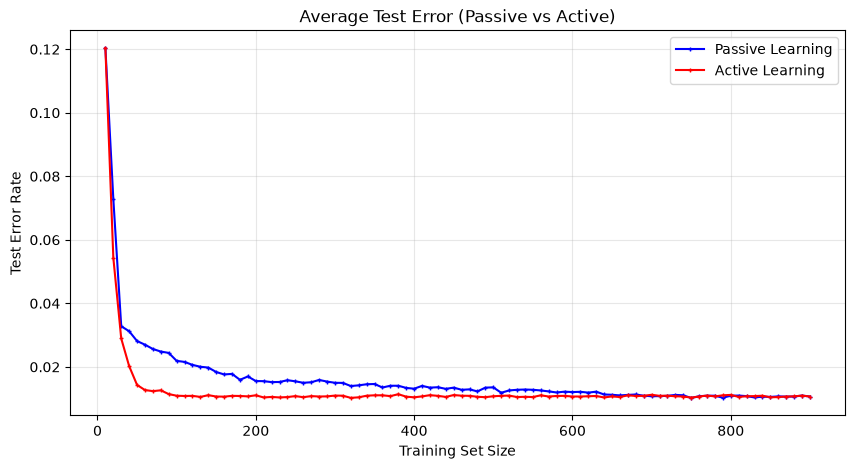

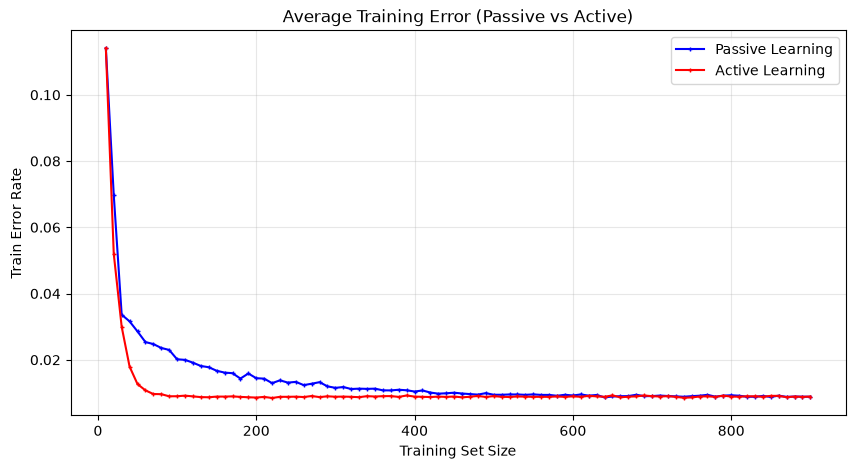

In [13]:
avg_passive_test_err = []
avg_passive_train_err = []
avg_active_test_err = []
avg_active_train_err = []

for m in train_set_size:
    avg_passive_test_err.append(np.mean(passive_err['test'][m]))
    avg_passive_train_err.append(np.mean(passive_err['train'][m]))
    avg_active_test_err.append(np.mean(active_err['test'][m]))
    avg_active_train_err.append(np.mean(active_err['train'][m]))

plt.figure(figsize=(10, 5))
plt.plot(train_set_size, avg_passive_test_err, label='Passive Learning', color='blue', marker='+', markersize=3)
plt.plot(train_set_size, avg_active_test_err, label='Active Learning', color='red', marker='+', markersize=3)
plt.title('Average Test Error (Passive vs Active)')
plt.xlabel('Training Set Size')
plt.ylabel('Test Error Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(train_set_size, avg_passive_train_err, label='Passive Learning', color='blue',marker='+', markersize=3)
plt.plot(train_set_size, avg_active_train_err, label='Active Learning', color='red',marker='+', markersize=3)
plt.title('Average Training Error (Passive vs Active)')
plt.xlabel('Training Set Size')
plt.ylabel('Train Error Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



- https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
- https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.euclidean_distances.html
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mode.html
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.softmax.html
- https://scikit-learn.org/stable/modules/generated/sklearn.cluster.SpectralClustering.html